# How to monitor Equatorien forest with optical image

It this new tutorial we will dowload image of landsat and sentinel-2 satellite to monitor the Equatorien forest
We will process as follow:
- Find the area of interest
- Download images
- Convert all images to the same spatial resolution (20m)
- Prepare the images
- Create a montly composite image of the year 2025
- Detect any change during this year using DL model
- Create statistiques

For the purpose of this study we will the planetary computer API. We could use the harmonize landsat-sentinel-2 product but the goal of this study is to learn all the step.

### 2. Analyse des images

In [1]:
from pyproj import Transformer
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import pandas as pd 
import contextily
from shapely.geometry import box
from pystac_client import Client
import planetary_computer
from odc.stac import stac_load
import os
import xarray as xr
import numpy as np
from datetime import datetime
import importlib
import hvplot.pandas
import geoviews as gv
#import hvplot.geopandas
import notebook_utils.utils_download_image as udi
importlib.reload(udi)



<module 'notebook_utils.utils_download_image' from 'c:\\Users\\a871169\\OneDrive - ATOS\\Bureau\\geospatiale\\satellite_image_processor\\notebook\\notebook_utils\\utils_download_image.py'>

In [2]:
# Ouvrir le fichier
s2_data = xr.open_dataset("data/choco_andino_pichincha/data_input/choco_andino_pichincha_sentinel2.nc")
landsat_data = xr.open_dataset("data/choco_andino_pichincha/data_input/choco_andino_pichincha_landsat-4.nc")

In [4]:
# ========== VOIR LES DIMENSIONS ==========
print("\n📏 Dimensions Sentinel-2:", s2_data.dims)

print("📏 Dimensions Landsat:", landsat_data.dims)



📏 Dimensions Sentinel-2: FrozenMappingWarningOnValuesAccess({'time': 131, 'y': 8852, 'x': 4456})
📏 Dimensions Landsat: FrozenMappingWarningOnValuesAccess({'y': 1476, 'x': 1487, 'time': 78})


In [5]:
# ========== VOIR LES DATES ==========
print("\n📅 Dates Sentinel-2:")
print(s2_data.time.values)

print("\n📅 Dates Landsat:")
print(landsat_data.time.values)



📅 Dates Sentinel-2:
['2024-01-06T15:36:29.024000000' '2024-01-11T15:36:21.024000000'
 '2024-01-21T15:36:21.024000000' '2024-01-26T15:36:29.024000000'
 '2024-01-31T15:36:21.024000000' '2024-02-10T15:36:21.024000000'
 '2024-02-15T15:36:29.024000000' '2024-02-25T15:36:29.024000000'
 '2024-03-01T15:36:31.024000000' '2024-03-06T15:36:19.024000000'
 '2024-03-11T15:36:31.024000000' '2024-03-16T15:36:29.024000000'
 '2024-03-21T15:36:31.024000000' '2024-03-26T15:36:29.024000000'
 '2024-03-31T15:36:21.024000000' '2024-04-05T15:36:29.024000000'
 '2024-04-10T15:36:31.024000000' '2024-04-15T15:36:29.024000000'
 '2024-04-20T15:36:31.024000000' '2024-05-10T15:36:31.024000000'
 '2024-05-15T15:36:29.024000000' '2024-05-20T15:36:31.024000000'
 '2024-05-25T15:36:29.024000000' '2024-05-30T15:36:31.024000000'
 '2024-06-09T15:36:31.024000000' '2024-06-24T15:36:29.024000000'
 '2024-06-29T15:36:31.024000000' '2024-07-04T15:36:29.024000000'
 '2024-07-09T15:36:31.024000000' '2024-07-14T15:36:29.024000000'
 '20

#### Analyse des acquisitions landsat et sentinel

Landsat acquiert des scènes rectangulaires (path/row) qui ne couvrent pas toujours toute la bbox : si une zone est à cheval sur la limite entre deux scènes, chaque scène ne couvre qu’une partie → d’où des images “incomplètes” (pixels nodata/noir).

Sentinel-2 acquiert des tuiles MGRS fixes : chaque tuile couvre toujours 100×100 km, et ODC (stac_load) assemble toutes les tuiles qui recouvrent la bbox → on obtiens une image complète, sans nodata sur ta zone.



In [6]:
for i, t in enumerate(s2_data.time.values):
    arr = s2_data['B02'][i].values
    valid = np.sum(arr > 0)
    total = arr.size
    print(f"{t}: {valid/total:.2%} pixels valides")

2024-01-06T15:36:29.024000000: 0.00% pixels valides
2024-01-11T15:36:21.024000000: 0.00% pixels valides
2024-01-21T15:36:21.024000000: 0.00% pixels valides
2024-01-26T15:36:29.024000000: 0.00% pixels valides
2024-01-31T15:36:21.024000000: 0.00% pixels valides
2024-02-10T15:36:21.024000000: 0.00% pixels valides
2024-02-15T15:36:29.024000000: 0.00% pixels valides
2024-02-25T15:36:29.024000000: 0.00% pixels valides
2024-03-01T15:36:31.024000000: 0.00% pixels valides
2024-03-06T15:36:19.024000000: 0.00% pixels valides
2024-03-11T15:36:31.024000000: 0.00% pixels valides
2024-03-16T15:36:29.024000000: 0.00% pixels valides
2024-03-21T15:36:31.024000000: 0.00% pixels valides
2024-03-26T15:36:29.024000000: 0.00% pixels valides
2024-03-31T15:36:21.024000000: 0.00% pixels valides
2024-04-05T15:36:29.024000000: 0.00% pixels valides
2024-04-10T15:36:31.024000000: 0.00% pixels valides
2024-04-15T15:36:29.024000000: 0.00% pixels valides
2024-04-20T15:36:31.024000000: 0.00% pixels valides
2024-05-10T1

On remarque bien que nos pixeles recouvre bien toutes notre bbox

In [7]:
for i, t in enumerate(landsat_data.time.values):
    arr = landsat_data['red'][i].values
    valid = np.sum(arr > 0)
    total = arr.size
    print(f"{t}: {valid/total:.2%} pixels valides")

2024-01-11T12:52:25.130287000: 51.22% pixels valides
2024-01-11T15:26:25.676024000: 100.00% pixels valides
2024-01-16T12:54:41.271962000: 92.97% pixels valides
2024-01-19T15:26:33.807441000: 100.00% pixels valides
2024-01-27T15:26:18.715809000: 100.00% pixels valides
2024-02-04T15:26:37.044202000: 100.00% pixels valides
2024-02-20T15:26:25.904282000: 100.00% pixels valides
2024-02-28T15:26:17.868210000: 100.00% pixels valides
2024-03-07T15:26:29.421244000: 100.00% pixels valides
2024-03-15T15:26:07.532779000: 100.00% pixels valides
2024-03-31T15:25:54.831530000: 100.00% pixels valides
2024-04-08T15:26:16.695375000: 100.00% pixels valides
2024-04-16T15:25:48.964095000: 100.00% pixels valides
2024-04-24T15:25:55.495188000: 100.00% pixels valides
2024-05-10T15:25:54.221246000: 100.00% pixels valides
2024-05-18T15:25:25.360590000: 100.00% pixels valides
2024-05-26T15:25:41.871363000: 100.00% pixels valides
2024-06-03T15:25:22.792478000: 100.00% pixels valides
2024-06-11T15:25:35.938691000:

Nous remarquons dans la liste des dates landsat que certains jours ont deux acquisition. Nous allons filtrer les dates et choisir seulement celle qui ont une acquisitions plus complète 

In [8]:
landsat_data = landsat_data.sortby('time')
landsat_filtered = []
list_date = landsat_data.time.values
i = 0
while i < len(list_date):
    date_i = pd.to_datetime(list_date[i]).strftime('%Y-%m-%d')
    # Check if next date is same day
    if i < len(list_date) - 1:
        date_next = pd.to_datetime(list_date[i+1]).strftime('%Y-%m-%d')
        if date_i == date_next:
            pixel_count_i = np.sum(landsat_data['red'][i].values > 0)
            pixel_count_next = np.sum(landsat_data['red'][i+1].values > 0)
            if pixel_count_next > pixel_count_i:
                landsat_filtered.append(landsat_data.isel(time=i+1))
            else:
                landsat_filtered.append(landsat_data.isel(time=i))
            i += 2  # skip both
            continue
    landsat_filtered.append(landsat_data.isel(time=i))
    i += 1
landsat_filtered = xr.concat(landsat_filtered, dim='time')
    

On va ensuite filtrer les scènes qui couvrent au moins 90% de la bbox car nous souhaitons des images les plus complètes possible

In [9]:
landsat_filtered_scenes = []
for i, t in enumerate(landsat_filtered.time.values):
    arr = landsat_filtered['red'][i].values
    valid = np.sum(arr > 0)
    total = arr.size
    if valid / total > 0.9:
        # garder cette scène
        landsat_filtered_scenes.append(landsat_filtered.isel(time=i))
landsat_filtered = xr.concat(landsat_filtered_scenes, dim='time')

In [10]:
print("\n📅 Dates Landsat des images filtrées:")
print(landsat_filtered.time.values)


📅 Dates Landsat des images filtrées:
['2024-01-11T15:26:25.676024000' '2024-01-16T12:54:41.271962000'
 '2024-01-19T15:26:33.807441000' '2024-01-27T15:26:18.715809000'
 '2024-02-04T15:26:37.044202000' '2024-02-20T15:26:25.904282000'
 '2024-02-28T15:26:17.868210000' '2024-03-07T15:26:29.421244000'
 '2024-03-15T15:26:07.532779000' '2024-03-31T15:25:54.831530000'
 '2024-04-08T15:26:16.695375000' '2024-04-16T15:25:48.964095000'
 '2024-04-24T15:25:55.495188000' '2024-05-10T15:25:54.221246000'
 '2024-05-18T15:25:25.360590000' '2024-05-26T15:25:41.871363000'
 '2024-06-03T15:25:22.792478000' '2024-06-11T15:25:35.938691000'
 '2024-06-19T15:25:30.298854000' '2024-06-27T15:25:21.711478000'
 '2024-07-05T15:25:38.445727000' '2024-07-13T15:25:43.617422000'
 '2024-07-21T15:25:53.730330000' '2024-07-29T15:25:46.190928000'
 '2024-08-06T15:25:51.068601000' '2024-08-14T15:25:53.720565000'
 '2024-08-22T15:26:03.785041000' '2024-08-30T15:26:04.698967000'
 '2024-09-07T15:26:12.378968000' '2024-09-15T15:26:0

In [11]:
# ========== LISTER LES BANDES ==========
print("\n🎨 Bandes Sentinel-2:")
print(list(s2_data.data_vars))

print("\n🎨 Bandes Landsat:")
print(list(landsat_filtered.data_vars))


🎨 Bandes Sentinel-2:
['B02', 'B03', 'B04', 'B08', 'B8A', 'B11', 'B12', 'SCL', 'spatial_ref']

🎨 Bandes Landsat:
['spatial_ref', 'blue', 'green', 'red', 'nir08', 'swir16', 'swir22', 'qa_pixel']


In [12]:

list_band = list(landsat_filtered.data_vars)[1:-1]  # Exclure 'lwir11' 
print(list_band)
for band_name in list_band:
    band = landsat_filtered[band_name]
    print(f"📊 Statistiques {band_name}:")
    print(f"  Min: {(band*0.0000275 - 0.2).min().values}")
    print(f"  Max: {(band*0.0000275 - 0.2).max().values}")
    print(f"  Mean: {(band*0.0000275 - 0.2).mean().values}")
    print(f"  Std: {(band*0.0000275 - 0.2).std().values}")
    print("-" * 30)
# statistiques pour la bande thermique (lwir11)
thermal_band = landsat_filtered['lwir11']
print(f"📊 Statistiques lwir11 (Thermal):")
print(f"  Min: {(thermal_band * 0.00341802 + 149.0).min().values}")
print(f"  Max: {(thermal_band * 0.00341802 + 149.0).max().values}")
print(f"  Mean: {(thermal_band * 0.00341802 + 149.0).mean().values}")
print(f"  Std: {(thermal_band * 0.00341802 + 149.0).std().values}")
print("-" * 30)

['blue', 'green', 'red', 'nir08', 'swir16', 'swir22']
📊 Statistiques blue:
  Min: -0.2
  Max: 1.6022125
  Mean: 0.3274069401983925
  Std: 0.3443663317406269
------------------------------
📊 Statistiques green:
  Min: -0.2
  Max: 1.6022125
  Mean: 0.3341188860666509
  Std: 0.3136834997511183
------------------------------
📊 Statistiques red:
  Min: -0.2
  Max: 1.6022125
  Mean: 0.3237030626311688
  Std: 0.3206646551172968
------------------------------
📊 Statistiques nir08:
  Min: -0.2
  Max: 1.5999850000000002
  Mean: 0.49001510482381583
  Std: 0.2274243249032393
------------------------------
📊 Statistiques swir16:
  Min: -0.2
  Max: 1.6022125
  Mean: 0.30070623983040273
  Std: 0.16855854263979406
------------------------------
📊 Statistiques swir22:
  Min: -0.2
  Max: 1.555655
  Mean: 0.21050864669502506
  Std: 0.13931507692817885
------------------------------


KeyError: "No variable named 'lwir11'. Variables on the dataset include ['spatial_ref', 'blue', 'green', 'red', 'nir08', ..., 'swir22', 'qa_pixel', 'y', 'x', 'time']"

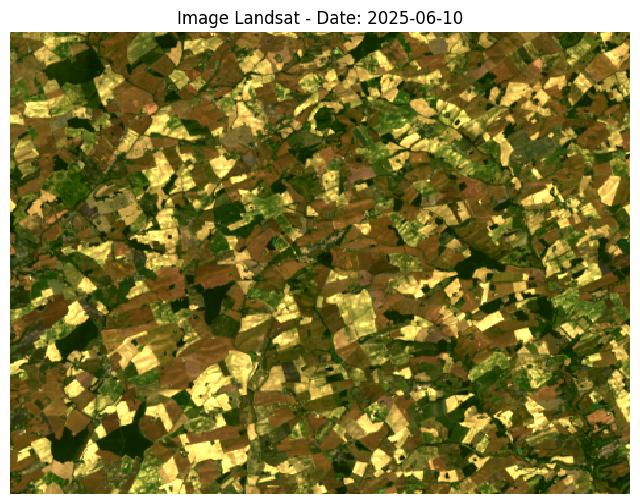

In [ ]:
# Pour une date (ex: time=0)
arr = np.stack([
    landsat_filtered['red'][0].values* 0.0000275 - 0.2,
    landsat_filtered['green'][0].values* 0.0000275 - 0.2,
    landsat_filtered['blue'][0].values* 0.0000275 - 0.2
], axis=0)  # shape: (3, y, x)

rgb_da = xr.DataArray(arr, dims=['bands', 'y', 'x'], coords={'bands': ['red', 'green', 'blue']})
plt.figure(figsize=(8, 6))
rgb_da.plot.imshow(robust=True)
plt.title(f"Image Landsat - Date: {pd.to_datetime(landsat_filtered.time[0].values).strftime('%Y-%m-%d')}")
plt.axis('off')
plt.show()

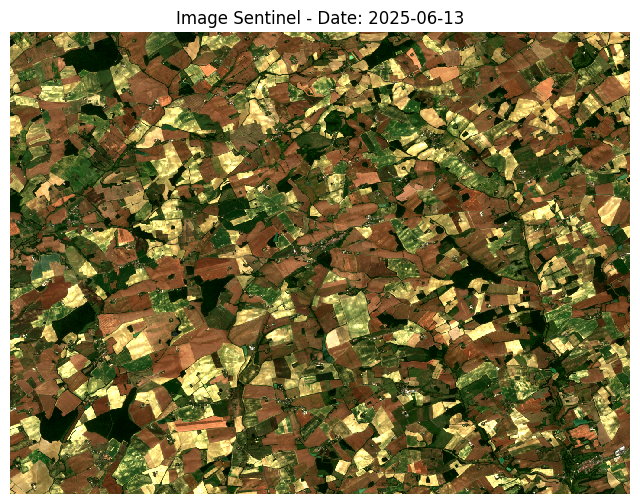

In [ ]:
# Pour une date (ex: time=0)
arr = np.stack([
    (s2_data['B04'][0].values/10000),
    (s2_data['B03'][0].values/10000),
    (s2_data['B02'][0].values/10000)
], axis=0)  # shape: (3, y, x)

rgb_da = xr.DataArray(arr, dims=['bands', 'y', 'x'], coords={'bands': ['B04', 'B03', 'B02']})
plt.figure(figsize=(8, 6))
rgb_da.plot.imshow(robust=True)
plt.title(f"Image Sentinel - Date: {pd.to_datetime(s2_data.time[0].values).strftime('%Y-%m-%d')}")
plt.axis('off')
plt.show()

T min: 27.0°C | T max: 46.9°C | T moy: 35.4°C


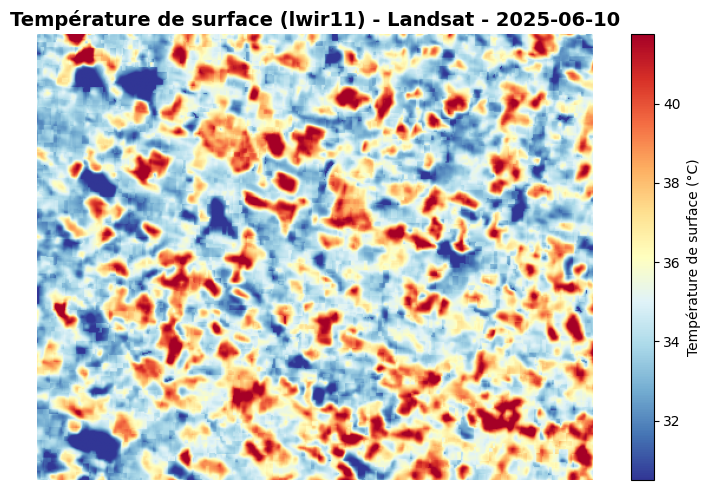

In [ ]:
# Température de surface en °C (Landsat Collection 2 Level-2 ST)
date_idx = 0
dn = landsat_filtered['lwir11'][date_idx, :, :].values.astype('float32')
# DN -> Kelvin
thermal_K = dn * 0.00341802 + 149.0
# Masquer le fill value (DN=0)
thermal_K[dn == 0] = np.nan
# Convertir en Celsius
thermal_C = thermal_K - 273.15

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(thermal_C, cmap='RdYlBu_r',
               vmin=np.nanpercentile(thermal_C, 2),
               vmax=np.nanpercentile(thermal_C, 98))
plt.colorbar(im, ax=ax, label='Température de surface (°C)')
ax.set_title(f"Température de surface (lwir11) - Landsat - {landsat_filtered.time.values[date_idx].astype('datetime64[D]')}",
             fontsize=14, fontweight='bold')
ax.axis('off')
print(f"T min: {np.nanmin(thermal_C):.1f}°C | T max: {np.nanmax(thermal_C):.1f}°C | T moy: {np.nanmean(thermal_C):.1f}°C")
plt.tight_layout()
plt.show()


### Récupération des parcelles de la zone

In [ ]:
import requests
import json
geom = {
    "type": "Polygon",
    "coordinates": [[
        [bbox_coords['west'], bbox_coords['south']],
        [bbox_coords['east'], bbox_coords['south']],
        [bbox_coords['east'], bbox_coords['north']],
        [bbox_coords['west'], bbox_coords['north']],
        [bbox_coords['west'], bbox_coords['south']]
    ]]
}
response = requests.get(
    "https://apicarto.ign.fr/api/cadastre/parcelle", # https://apicarto.ign.fr/api/cadastre/parcelle  https://apicarto.ign.fr/api/rpg/v2/parcelles/2022
    params={"geom": json.dumps(geom)},
    headers={"Accept": "application/json"}
)

if response.status_code == 200:
    data = response.json()

In [ ]:

import requests
import json
import pyproj

# === Extraction des coordonnées directement depuis le dataset chargé ===
try:
    crs_wkt = s2_data['spatial_ref'].attrs['crs_wkt']
    src_crs_s2 = pyproj.CRS.from_wkt(crs_wkt)
except (KeyError, AttributeError):
    src_crs_s2 = pyproj.CRS.from_epsg(32631)  # UTM 31N (France)

print(f"CRS du dataset S2 : EPSG:{src_crs_s2.to_epsg()}")

# Transformer les coordonnées x/y (UTM) vers WGS84
t = pyproj.Transformer.from_crs(src_crs_s2, "EPSG:4326", always_xy=True)
west, south = t.transform(float(s2_data.x.min()), float(s2_data.y.min()))
east, north = t.transform(float(s2_data.x.max()), float(s2_data.y.max()))
print(f"Emprise WGS84 : W={west:.5f}°  S={south:.5f}°  E={east:.5f}°  N={north:.5f}°")

geom_wgs84 = {
    "type": "Polygon",
    "coordinates": [[
        [west, south], [east, south], [east, north],
        [west, north], [west, south]
    ]]
}

# === Appel API RPG - Registre Parcellaire Graphique (parcelles agricoles 2023) ===
response = requests.get(
    "https://apicarto.ign.fr/api/cadastre/parcelle", # https://apicarto.ign.fr/api/cadastre/parcelle  https://apicarto.ign.fr/api/rpg/v2/parcelles/2022
    params={"geom": json.dumps(geom_wgs84)},
    headers={"Accept": "application/json"}
)

if response.status_code == 200:
    rpg_data = response.json()
    parcelles_gdf = gpd.GeoDataFrame.from_features(rpg_data.get('features', []), crs="EPSG:4326")
    print(f"\n✅ {len(parcelles_gdf)} parcelles agricoles récupérées (RPG 2023)")
    if 'code_cultu' in parcelles_gdf.columns:
        print("\n🌾 Répartition des cultures (top 10) :")
        print(parcelles_gdf['code_cultu'].value_counts().head(10).to_string())
else:
    print(f"❌ Erreur API RPG : {response.status_code}\n{response.text[:300]}")
    parcelles_gdf = gpd.GeoDataFrame(columns=['geometry'], crs="EPSG:4326")


CRS du dataset S2 : EPSG:32630
Emprise WGS84 : W=0.65189°  S=43.70259°  E=0.83573°  N=43.80046°

✅ 1000 parcelles agricoles récupérées (RPG 2023)


In [ ]:
import geopandas as gpd

# Construire la bbox (xmin,ymin,xmax,ymax en EPSG:4326)
bbox_str = f"{west},{south},{east},{north},EPSG:4326"

# Requête WFS
wfs_url = "https://data.geopf.fr/wfs/ows"
params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typeName": "RPG.2023:parcelles_graphiques",
    "outputFormat": "application/json",
    "bbox": bbox_str,
    "srsName": "EPSG:4326"
}

query_string = "&".join([f"{k}={v}" for k, v in params.items()])
url = f"{wfs_url}?{query_string}"

parcelles_gdf = gpd.read_file(url)
print(f"✅ {len(parcelles_gdf)} parcelles")

✅ 4343 parcelles


In [ ]:
parcelles_gdf.head()

,geometry,gid,numero,feuille,section,code_dep,nom_com,code_com,com_abs,code_arr,idu,contenance,code_insee
0,"MULTIPOLYGON (((0.65221 43.70364, 0.65208 43.7...",25480706,0187,2,0A,32,Montaut-les-Créneaux,279,000,000,322790000A0187,3004,32279
1,"MULTIPOLYGON (((0.81494 43.72672, 0.81485 43.7...",25480724,0187,2,0A,32,Saint-Antonin,359,000,000,323590000A0187,2120,32359
2,"MULTIPOLYGON (((0.77611 43.78751, 0.77648 43.7...",25480727,0187,2,0A,32,Saint-Brès,366,000,000,323660000A0187,15275,32366
3,"MULTIPOLYGON (((0.7637 43.74342, 0.7639 43.743...",25484635,0187,2,0B,32,Puycasquier,335,000,000,323350000B0187,343,32335
4,"MULTIPOLYGON (((0.6884 43.7503, 0.68899 43.750...",25487842,0187,2,0C,32,Tourrenquets,453,000,000,324530000C0187,1238,32453


Filtrer les parcelle par code culture 

In [ ]:
# Télécharger toutes les parcelles
parcelles_gdf = gpd.read_file(url)

# Filtrer pour garder seulement les cultures agricoles
codes_exclus = ['BOP', 'SPL', 'DIV', 'J7P']  # Forêts, surfaces pastorales, divers, jachères
parcelles_cultivables = parcelles_gdf[~parcelles_gdf['code_cultu'].isin(codes_exclus)]

print(f"✅ {len(parcelles_cultivables)} parcelles cultivables sur {len(parcelles_gdf)} totales")
print("\n🌾 Cultures présentes :")
print(parcelles_cultivables['code_cultu'].value_counts())

✅ 4339 parcelles cultivables sur 4343 totales

🌾 Cultures présentes :
code_cultu
JAC    925
BTH    604
TRN    498
PPH    433
BTA    402
BOR    200
LUZ    176
ORH    137
SNE    114
BDH     94
PTR     84
SOJ     82
PHI     54
PCH     49
FVL     46
MIS     44
AIL     37
BFS     35
SOG     28
TTH     25
ORP     23
AVH     22
MPC     22
LEC     22
MLC     19
VRC     16
VRG     15
AAR     14
TRE     12
SRS     11
EPE     11
CZH      9
MLG      7
MLF      6
PRU      6
LIP      6
CPL      6
PHS      5
VES      5
MDI      5
AVP      4
SPH      3
OLI      3
LIH      2
LAV      2
FLA      2
CAG      2
BTN      2
PPR      1
PEP      1
PHF      1
FEV      1
CSS      1
BTP      1
ART      1
OIG      1
CBT      1
FLP      1
Name: count, dtype: int64


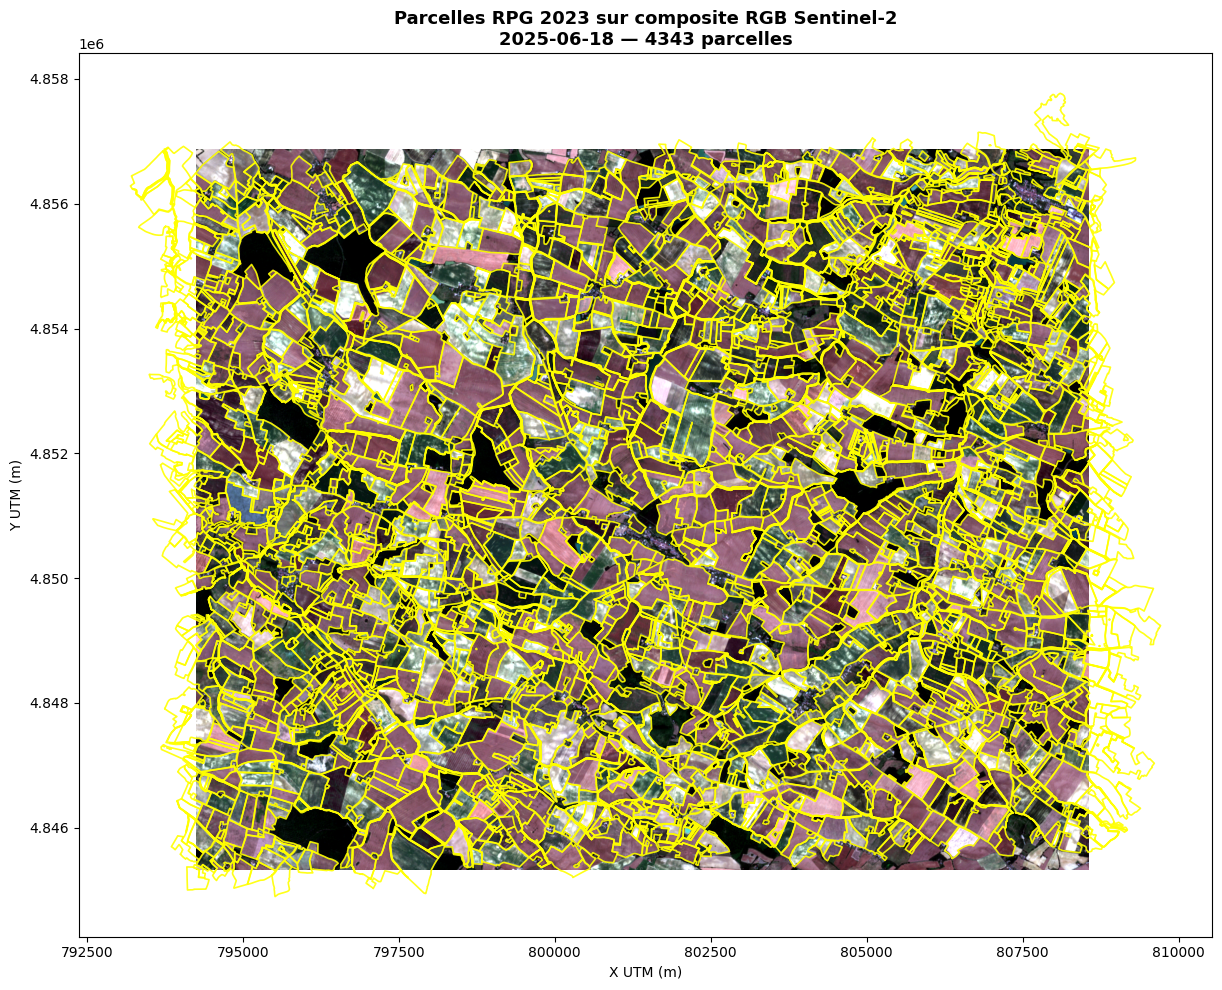

In [ ]:

# === Affichage des parcelles sur l'image RGB Sentinel-2 ===
date_idx = 1

def prepare_rgb_s2(dataset, date_idx):
    r = dataset['B04'][date_idx].values.astype('float32') / 10000
    g = dataset['B03'][date_idx].values.astype('float32') / 10000
    b = dataset['B02'][date_idx].values.astype('float32') / 10000
    nodata = (r <= 0) | (g <= 0) | (b <= 0)
    r[nodata] = g[nodata] = b[nodata] = np.nan
    def stretch(band):
        v = band[~np.isnan(band)]
        p2, p98 = np.percentile(v, 2), np.percentile(v, 98)
        return np.clip((band - p2) / (p98 - p2 + 1e-10), 0, 1)
    rgb = np.dstack([stretch(r), stretch(g), stretch(b)])
    rgb[nodata] = 0
    return rgb

rgb = prepare_rgb_s2(s2_data, date_idx)
extent_s2 = [float(s2_data.x.min()), float(s2_data.x.max()),
             float(s2_data.y.min()), float(s2_data.y.max())]

# Reprojeter les parcelles dans le CRS du dataset S2
parcelles_proj = parcelles_gdf.to_crs(epsg=src_crs_s2.to_epsg()) if not parcelles_gdf.empty else parcelles_gdf

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(rgb, extent=extent_s2, origin='upper', aspect='auto')
if not parcelles_proj.empty:
    parcelles_proj.plot(ax=ax, facecolor='none', edgecolor='yellow', linewidth=1.2, alpha=0.9)
ax.set_title(
    f"Parcelles RPG 2023 sur composite RGB Sentinel-2\n"
    f"{s2_data.time.values[date_idx].astype('datetime64[D]')} — {len(parcelles_gdf)} parcelles",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel("X UTM (m)")
ax.set_ylabel("Y UTM (m)")
plt.tight_layout()
plt.show()


#### 2.2 Statistiques de l'image

evolution moyen du NDVI par parcelle

Supprimer les outlier

supprimer les nuages

mettre tout sous la même résolution spatiale 10m 

Fusionner landsat et sentinel-2 pour n'avoir qu'un seul dataset avec les 2 types d'images

Faire une serie temporelle de NDVI sur un champs
Faire une serie temporelle moyenne de la temperature sur un champs 
extraire différent champs avec RGB et faire la moyenne de la température et NDVI pour chaque champs

In [ ]:
    
        response = requests.get(
            "https://apicarto.ign.fr/api/cadastre/parcelle", # https://apicarto.ign.fr/api/cadastre/parcelle  https://apicarto.ign.fr/api/rpg/v2/parcelles/2022
            params={"geom": json.dumps(geom)},
            headers={"Accept": "application/json"}
        )
        
        if response.status_code == 200:
            data = response.json()
            state['data'] = data

NameError: name 'state' is not defined